In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# =========================================================
# 1. 데이터 로드
# =========================================================

base_path = r"C:\Users\82105\Downloads\Dataset_전자부품(배터리팩)_예지보전_AI_데이터셋"

df_train = pd.read_csv(base_path + r"\data\raw_data\train\df_train_bfsc.csv")

df_ok_1 = pd.read_csv(base_path + r"\data\raw_data\train\df_ok_1_bfsc.csv")
df_ok_2 = pd.read_csv(base_path + r"\data\raw_data\train\df_ok_2_bfsc.csv")
df_ng_1 = pd.read_csv(base_path + r"\data\raw_data\train\df_ng_1_bfsc.csv")
df_ng_2 = pd.read_csv(base_path + r"\data\raw_data\train\df_ng_2_bfsc.csv")

label_ng_1 = pd.read_csv(base_path + r"\data\preprocessed\test\WeldingTest_03_NG_Label.csv")["label"]
label_ng_2 = pd.read_csv(base_path + r"\data\preprocessed\test\WeldingTest_04_NG_Label.csv")["label"]

label_ok_1 = np.zeros(len(df_ok_1), dtype=int)
label_ok_2 = np.zeros(len(df_ok_2), dtype=int)


# =========================================================
# 2. train data만으로 SetPower별 RealPower 정상 기준 학습
# =========================================================

def fit_setpower_realpower_model(train_df, setpower_col="SetPower", realpower_col="RealPower", min_iqr=1e-6):
    train_df = train_df.copy()
    train_df[realpower_col] = pd.to_numeric(train_df[realpower_col], errors="coerce")
    train_df = train_df.dropna(subset=[setpower_col, realpower_col])

    model_stat = {}

    for sp_value, group_df in train_df.groupby(setpower_col):
        values = group_df[realpower_col]

        median = values.median()
        q1 = values.quantile(0.25)
        q3 = values.quantile(0.75)
        iqr = q3 - q1

        if pd.isna(iqr) or iqr == 0:
            iqr = min_iqr

        model_stat[sp_value] = {
            "median": median,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "count": len(group_df),
        }

    trained_setpowers = sorted(model_stat.keys())

    return {
        "setpower_col": setpower_col,
        "realpower_col": realpower_col,
        "model_stat": model_stat,
        "trained_setpowers": trained_setpowers,
        "min_iqr": min_iqr,
    }


# =========================================================
# 3. 개선 포인트:
#    train에 없는 SetPower는 global이 아니라 가장 가까운 SetPower 기준 사용
# =========================================================

def find_nearest_setpower(sp_value, trained_setpowers):
    return min(trained_setpowers, key=lambda x: abs(x - sp_value))


def judge_setpower_realpower_improved(model, test_df, threshold=5):
    result_df = test_df.copy()

    setpower_col = model["setpower_col"]
    realpower_col = model["realpower_col"]
    model_stat = model["model_stat"]
    trained_setpowers = model["trained_setpowers"]

    result_df[realpower_col] = pd.to_numeric(result_df[realpower_col], errors="coerce")

    robust_scores = []
    judge_labels = []
    used_standards = []
    medians = []
    iqrs = []

    for _, row in result_df.iterrows():
        sp_value = row[setpower_col]
        realpower_value = row[realpower_col]

        if sp_value in model_stat:
            used_sp = sp_value
            used_standard = f"SetPower_{sp_value}"
        else:
            used_sp = find_nearest_setpower(sp_value, trained_setpowers)
            used_standard = f"nearest_SetPower_{used_sp}"

        stat = model_stat[used_sp]
        median = stat["median"]
        iqr = stat["iqr"]

        if pd.isna(realpower_value):
            robust_score = np.nan
            judge_label = 1
        else:
            robust_score = abs(realpower_value - median) / iqr
            judge_label = 1 if robust_score > threshold else 0

        robust_scores.append(robust_score)
        judge_labels.append(judge_label)
        used_standards.append(used_standard)
        medians.append(median)
        iqrs.append(iqr)

    result_df["realpower_robust_score"] = robust_scores
    result_df["judge_label"] = judge_labels
    result_df["pred_label"] = judge_labels
    result_df["used_standard"] = used_standards
    result_df["setpower_realpower_median"] = medians
    result_df["setpower_realpower_iqr"] = iqrs

    return result_df


# =========================================================
# 4. 학습 및 예측
# =========================================================

model = fit_setpower_realpower_model(df_train)

pred_ok_1 = judge_setpower_realpower_improved(model, df_ok_1, threshold=5)
pred_ok_2 = judge_setpower_realpower_improved(model, df_ok_2, threshold=5)
pred_ng_1 = judge_setpower_realpower_improved(model, df_ng_1, threshold=5)
pred_ng_2 = judge_setpower_realpower_improved(model, df_ng_2, threshold=5)


# =========================================================
# 5. 평가
#    정답지는 여기서만 사용. 모델 학습에는 사용하지 않음.
# =========================================================

def print_eval(name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"\n{name}")
    print(cm)
    print(f"Acc={acc:.3f}, Precision={precision:.3f}, Recall={recall:.3f}, F1={f1:.3f}")


print_eval("df_ok_1_bfsc", label_ok_1, pred_ok_1["pred_label"])
print_eval("df_ok_2_bfsc", label_ok_2, pred_ok_2["pred_label"])
print_eval("df_ng_1_bfsc", label_ng_1, pred_ng_1["pred_label"])
print_eval("df_ng_2_bfsc", label_ng_2, pred_ng_2["pred_label"])


# =========================================================
# 6. NG2에서 놓치던 SetPower=35 확인
# =========================================================

check_ng2 = pred_ng_2.copy()
check_ng2["true_label"] = label_ng_2.values

print(
    check_ng2[
        (check_ng2["SetPower"] == 35)
    ][[
        "PageNo",
        "cycle_id",
        "order",
        "SetPower",
        "RealPower",
        "true_label",
        "pred_label",
        "realpower_robust_score",
        "used_standard",
    ]]
)


df_ok_1_bfsc
[[1950    0]
 [   0    0]]
Acc=1.000, Precision=0.000, Recall=0.000, F1=0.000

df_ok_2_bfsc
[[1872    0]
 [   0    0]]
Acc=1.000, Precision=0.000, Recall=0.000, F1=0.000

df_ng_1_bfsc
[[1034    0]
 [   0   19]]
Acc=1.000, Precision=1.000, Recall=1.000, F1=1.000

df_ng_2_bfsc
[[ 76   2]
 [  0 273]]
Acc=0.994, Precision=0.993, Recall=1.000, F1=0.996
     PageNo  cycle_id  order  SetPower  RealPower  true_label  pred_label  \
13       14         1     14        35        692           0           0   
52       14         2     53        35        692           0           0   
91       14         3     92        35          0           1           1   
130      14         4    131        35        126           1           1   
169      14         5    170        35        126           1           1   
208      14         6    209        35        126           1           1   
247      14         7    248        35        127           1           1   
286      14         

c:\Users\82105\miniconda3\envs\KMAP\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 54032 (\N{HANGUL SYLLABLE PAN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\82105\miniconda3\envs\KMAP\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\82105\miniconda3\envs\KMAP\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\82105\miniconda3\envs\KMAP\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\82105\miniconda3\envs\KMAP\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
c:\Users\82105\miniconda3\envs\KMAP\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 4

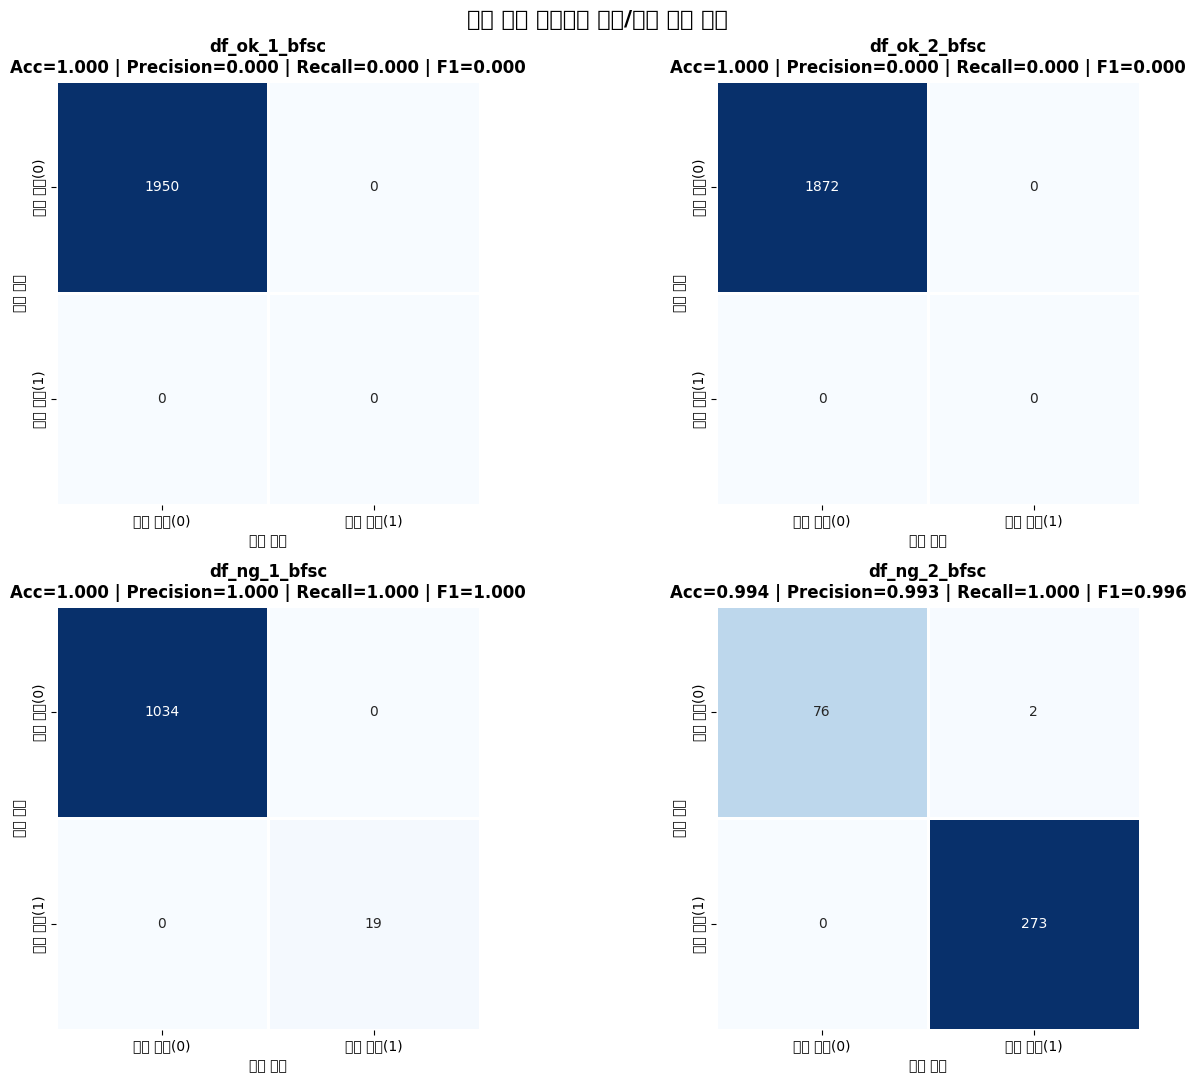

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# 7. 데이터별 Confusion Matrix 시각화
# =========================================================

eval_items = [
    ("df_ok_1_bfsc", label_ok_1, pred_ok_1["pred_label"]),
    ("df_ok_2_bfsc", label_ok_2, pred_ok_2["pred_label"]),
    ("df_ng_1_bfsc", label_ng_1, pred_ng_1["pred_label"]),
    ("df_ng_2_bfsc", label_ng_2, pred_ng_2["pred_label"]),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for ax, (data_name, y_true, y_pred) in zip(axes, eval_items):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        square=True,
        linewidths=1,
        linecolor="white",
        xticklabels=["판별 정상(0)", "판별 불량(1)"],
        yticklabels=["실제 정상(0)", "실제 불량(1)"],
        ax=ax
    )

    ax.set_title(
        f"{data_name}\n"
        f"Acc={acc:.3f} | Precision={precision:.3f} | Recall={recall:.3f} | F1={f1:.3f}",
        fontsize=12,
        fontweight="bold"
    )

    ax.set_xlabel("판별 결과")
    ax.set_ylabel("실제 라벨")

plt.suptitle("개선 모델 데이터별 정상/불량 판별 결과", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()